# Market Making Simulation: Naive vs Avellaneda–Stoikov
**BM, GBM and covariance-aware multivariate mid-price dynamics**

*Companion notebook — Starting Finance Club PoliTo*

---

## 1. Setup

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os, warnings
import pandas as pd
from IPython.display import display, Image
warnings.filterwarnings('ignore')

# plot parameters
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.dpi': 120,
})

OUTPUT_DIR = os.getcwd()
os.makedirs(OUTPUT_DIR, exist_ok=True)

P = dict(
    S0        = 100.0,  # initial price
    T         = 1.0,    # time horizon
    n_steps   = 1000,
    sigma_BM  = 1.5,
    mu_GBM    = 0.0,
    sigma_GBM = 0.015,
    gamma     = 0.1,    # MM risk adversion parameter
    k         = 1.5,    # order book parameers
    A         = 140.0,
    N_MC      = 5000,
    seed      = 42,
)
P['dt'] = P['T'] / P['n_steps'] # time discretization

delta_opt = (1.0 / P['gamma']) * np.log(1.0 + P['gamma'] / P['k']) # optimal delta computation
print(f'Optimal half-spread delta* = {delta_opt:.4f}')
print(f'Time step          dt      = {P["dt"]:.4f}')

Optimal half-spread delta* = 0.6454
Time step          dt      = 0.0010


## 2. Article Map and Mathematical Notes

The following cells keep the LaTeX/model explanations from the commented companion notebook, while the executable structure remains the one of `articolo1_applicazione.ipynb`.

### 1. Article Map

Article 1 builds a clean benchmark for high-frequency market making under the Avellaneda–Stoikov idea:

- define the limit order book and reduced-form fill process;
- compare naive symmetric quoting with inventory-aware quoting;
- run ABM and GBM mid-price dynamics with the same execution/accounting engine;
- extend to a covariance-aware multi-asset setting where scalar inventory risk becomes portfolio covariance risk.

### 2. Single-Asset Core

The baseline arithmetic mid-price model is

$$
dS_t = \sigma\,dW_t.
$$

The dealer maximises expected exponential (CARA) utility of terminal wealth

$$
\mathbb{E}\bigl[-e^{-\gamma W_T}\bigr], \quad W_T = X_T + q_T S_T,
$$

where $X_T$ is cash, $q_T$ is terminal inventory, and $\gamma>0$ is risk aversion.

The HJB approach (Avellaneda–Stoikov 2008) yields the **reservation price**

$$
r_t = S_t - q_t\,\gamma\,\sigma^2\,(T-t),
$$

which shifts quotes toward the side that reduces $q_t$.
For exponential fill intensity $\lambda(\delta)=A\,e^{-k\delta}$,
the optimal liquidity half-spread is constant:

$$
\delta^* = \frac{1}{\gamma}\ln\!\left(1+\frac{\gamma}{k}\right).
$$

The **AS bid/ask quotes** are therefore

$$
p^b_t = r_t - \delta^*, \qquad p^a_t = r_t + \delta^*.
$$

### 3. Why GBM Changes the Risk Scale

Under geometric Brownian motion,

$$
dS_t = \sigma_{\mathrm{GBM}}\,S_t\,dW_t,
$$

the **dollar volatility** of one share is state-dependent: $\sigma_{\mathrm{GBM}}\,S_t$.
To match dollar-scale risk with the ABM case we set $\sigma_{\mathrm{GBM}}\cdot S_0 = \sigma_{\mathrm{BM}}$.

The heuristic reservation price used in the simulation is

$$
r_t^{\mathrm{GBM}} = S_t - q_t\,\gamma\,(\sigma_{\mathrm{GBM}}\,S_t)^2\,(T-t),
$$

so the inventory penalty grows with $S_t^2$: a high-price regime magnifies inventory risk.

## 2. Mid-Price Dynamics

**ABM**: $dS_t = \sigma_{\mathrm{BM}}\,dW_t$

**GBM**: $dS_t = \sigma_{\mathrm{GBM}}\,S_t\,dW_t$ (zero drift for clarity)

In [3]:
def sim_BM(dW, S0, sigma):
    '''Arithmetic Brownian motion'''
    S = np.empty(len(dW) + 1)
    S[0] = S0
    for i in range(len(dW)):
        S[i+1] = S[i] + sigma * dW[i]
    return S


def sim_GBM(dW, S0, mu, sigma, dt):
    '''Geometric Brownian motion (Euler-log scheme)'''
    S = np.empty(len(dW) + 1)
    S[0] = S0
    drift = (mu - 0.5 * sigma**2) * dt
    for i in range(len(dW)):
        S[i+1] = S[i] * np.exp(drift + sigma * dW[i])
    return S

## 3. Execution / Fill Model

$\lambda(\delta) = A\,e^{-k\delta}$, $P_{\text{fill}} = 1 - e^{-\lambda\,\Delta t}$

In [4]:
def fill_probs(S, p_bid, p_ask, A, k, dt):
    '''Per-step fill probabilities from exponential intensity model'''
    lam_b = A * np.exp(-k * max(S - p_bid, 0.0))
    lam_a = A * np.exp(-k * max(p_ask - S,  0.0))
    return 1.0 - np.exp(-lam_b * dt), 1.0 - np.exp(-lam_a * dt)

## 4. Strategies

All quoting functions share signature `(S, q, t, **kw) -> (p_bid, p_ask)`.

**Naive**: $p^{b/a} = S \mp \delta^*$, $\delta^* = \frac{1}{\gamma}\ln\!\bigl(1+\frac{\gamma}{k}\bigr)$

**AS-BM**: $p^{b/a} = r \mp \delta^*$, $r = S - q\gamma\sigma_{\mathrm{BM}}^2(T-t)$

**AS-GBM**: same but $\sigma_{\mathrm{eff}} = \sigma_{\mathrm{GBM}}\cdot S$ (local vol)

In [5]:
def quote_naive(S, q, t, gamma, k, **_):
    delta = (1.0/gamma) * np.log(1.0 + gamma/k)
    return S - delta, S + delta


def quote_as_BM(S, q, t, gamma, k, sigma_BM, T, **_):
    tau = max(T - t, 1e-9)
    r = S - q * gamma * sigma_BM**2 * tau
    delta = (1.0/gamma) * np.log(1.0 + gamma/k)
    return r - delta, r + delta


def quote_as_GBM(S, q, t, gamma, k, sigma_GBM, T, **_):
    tau = max(T - t, 1e-9)
    sig_eff = sigma_GBM * S
    r = S - q * gamma * sig_eff**2 * tau
    delta = (1.0/gamma) * np.log(1.0 + gamma/k)
    return r - delta, r + delta

In [6]:
def run_sim(t_arr, S, U_bid, U_ask, qfn, dt, **kw):
    '''
    Simulate one strategy on a fixed price path.
    kw must contain A and k (used by fill_probs); all kw forwarded to qfn.
    '''
    A = kw['A']; k = kw['k']
    n = len(S) - 1
    inv  = np.zeros(n+1)  # inventory history
    cash = np.zeros(n+1)  # cash history
    pnl  = np.zeros(n+1)  # profit-loss history
    bids = np.zeros(n+1)  # bid prices history
    asks = np.zeros(n+1)  # ask prices history
    q, c = 0, 0.0         # q number of stocks, c cash
    turnover = 0          # turnover counter
    for i in range(n):
        s = S[i]; t = t_arr[i]      # saving mid-price and time
        pb, pa = qfn(s, q, t, **kw) # calling the pricing strategy
        bids[i] = pb; asks[i] = pa
        pfb, pfa = fill_probs(s, pb, pa, A, k, dt) # success probabilites computatioin
        if U_bid[i] < pfb:
            q += 1;  c -= pb
            turnover += 1
        if U_ask[i] < pfa:
            q -= 1;  c += pa
            turnover += 1

        inv[i+1]  = q
        cash[i+1] = c
        pnl[i+1]  = c + q * S[i+1]

    pb, pa = qfn(S[-1], q, t_arr[-1], **kw)
    bids[-1] = pb; asks[-1] = pa
    return dict(inv=inv, cash=cash, pnl=pnl, bids=bids, asks=asks,
                turnover=turnover, inv_std=np.std(inv))

## 5. Single-Path Toy Example — Arithmetic Brownian Motion

In [ ]:
rng   = np.random.default_rng(P['seed'])
dW_BM = rng.normal(0, np.sqrt(P['dt']), P['n_steps']) # BM standard increments
Ub_BM = rng.random(P['n_steps'])
Ua_BM = rng.random(P['n_steps'])

t_arr = np.linspace(0, P['T'], P['n_steps']+1)  # time discretization
S_BM  = sim_BM(dW_BM, P['S0'], P['sigma_BM'])   # BM simulation

# kw dicts include A and k so qfn and fill_probs share them via **kw
kw_naive  = dict(gamma=P['gamma'], k=P['k'], A=P['A'])
kw_as_bm  = dict(gamma=P['gamma'], k=P['k'], A=P['A'],
                 sigma_BM=P['sigma_BM'], T=P['T'])

r_naive_BM = run_sim(t_arr, S_BM, Ub_BM, Ua_BM, quote_naive, P['dt'], **kw_naive) # naive strategy
r_as_BM    = run_sim(t_arr, S_BM, Ub_BM, Ua_BM, quote_as_BM, P['dt'], **kw_as_bm) # inventory-based strategy

print(f'BM | Naive  terminal PnL = {r_naive_BM["pnl"][-1]:+8.3f}'
      f'  terminal inv = {r_naive_BM["inv"][-1]:+5.0f}')
print(f'BM | AS     terminal PnL = {r_as_BM["pnl"][-1]:+8.3f}'
      f'  terminal inv = {r_as_BM["inv"][-1]:+5.0f}')

BM | Naive  terminal PnL =  +79.781  terminal inv =    -9
BM | AS     terminal PnL =  +63.240  terminal inv =    +4


## 6. Single-Path Toy Example — Geometric Brownian Motion

In [ ]:
dW_GBM = rng.normal(0, np.sqrt(P['dt']), P['n_steps'])
Ub_GBM = rng.random(P['n_steps'])
Ua_GBM = rng.random(P['n_steps'])

S_GBM  = sim_GBM(dW_GBM, P['S0'], P['mu_GBM'], P['sigma_GBM'], P['dt'])

kw_as_gbm = dict(gamma=P['gamma'], k=P['k'], A=P['A'],
                 sigma_GBM=P['sigma_GBM'], T=P['T'])

r_naive_GBM = run_sim(t_arr, S_GBM, Ub_GBM, Ua_GBM, quote_naive,  P['dt'], **kw_naive)
r_as_GBM    = run_sim(t_arr, S_GBM, Ub_GBM, Ua_GBM, quote_as_GBM, P['dt'], **kw_as_gbm)

print(f'GBM | Naive  terminal PnL = {r_naive_GBM["pnl"][-1]:+8.3f}'
      f'  terminal inv = {r_naive_GBM["inv"][-1]:+5.0f}')
print(f'GBM | AS     terminal PnL = {r_as_GBM["pnl"][-1]:+8.3f}'
      f'  terminal inv = {r_as_GBM["inv"][-1]:+5.0f}')

GBM | Naive  terminal PnL =  +67.870  terminal inv =    -3
GBM | AS     terminal PnL =  +69.156  terminal inv =    -5


## 7. Monte Carlo Comparison

N = 5,000 paths per dynamics.

In [ ]:
# simulation function
def mc_compare(sim_fn, qfn_naive, qfn_as, kw_naive, kw_as, P, seed_base):
    N = P['N_MC']; n = P['n_steps']
    t_arr = np.linspace(0, P['T'], n+1)
    master = np.random.default_rng(seed_base)
    dW_all = master.normal(0, np.sqrt(P['dt']), (N, n))
    Ub_all = master.random((N, n))
    Ua_all = master.random((N, n))
    pnl_n  = np.zeros(N); pnl_as  = np.zeros(N)
    inv_n  = np.zeros(N); inv_as  = np.zeros(N)

    turnover_naive = np.zeros(N)
    turnover_as = np.zeros(N)

    inv_std_naive = np.zeros(N)
    inv_std_as = np.zeros(N)

    for m in range(N):
        S  = sim_fn(dW_all[m])
        Ub = Ub_all[m]; Ua = Ua_all[m]
        rn = run_sim(t_arr, S, Ub, Ua, qfn_naive, P['dt'], **kw_naive)
        ra = run_sim(t_arr, S, Ub, Ua, qfn_as,    P['dt'], **kw_as)
        pnl_n[m]  = rn['pnl'][-1];  inv_n[m]  = rn['inv'][-1]
        pnl_as[m] = ra['pnl'][-1];  inv_as[m] = ra['inv'][-1]

        turnover_naive[m] = rn['turnover']
        turnover_as[m] = ra['turnover']

        inv_std_naive[m] = rn['inv_std']
        inv_std_as[m] = ra['inv_std']

    return dict(pnl_n=pnl_n, pnl_as=pnl_as, inv_n=inv_n, inv_as=inv_as,
                turnover_naive=turnover_naive, turnover_as=turnover_as,
                inv_std_naive=inv_std_naive, inv_std_as=inv_std_as)

In [ ]:
print(f'Running BM Monte Carlo ({P["N_MC"]} paths) ...')
mc_BM = mc_compare(
    sim_fn    = lambda dW: sim_BM(dW, P['S0'], P['sigma_BM']),
    qfn_naive = quote_naive,
    qfn_as    = quote_as_BM,
    kw_naive  = kw_naive,
    kw_as     = kw_as_bm,
    P         = P,
    seed_base = 1000,
)
print('BM MC done.')

Running BM Monte Carlo (5000 paths) ...
BM MC done.


In [ ]:
print(f'Running GBM Monte Carlo ({P["N_MC"]} paths) ...')
mc_GBM = mc_compare(
    sim_fn    = lambda dW: sim_GBM(dW, P['S0'], P['mu_GBM'], P['sigma_GBM'], P['dt']),
    qfn_naive = quote_naive,
    qfn_as    = quote_as_GBM,
    kw_naive  = kw_naive,
    kw_as     = kw_as_gbm,
    P         = P,
    seed_base = 2000,
)
print('GBM MC done.')

Running GBM Monte Carlo (5000 paths) ...
GBM MC done.


In [ ]:
def stats(pnl, inv, turnover, inv_std):
    mu = np.mean(pnl)
    sd = np.std(pnl)
    return dict(mean_pnl=mu,
                std_pnl=sd,
                sharpe=mu/(sd+1e-12),
                mean_absinv=np.mean(np.abs(inv)),
                mean_inv_std=np.mean(inv_std),
                mean_turnover=np.mean(turnover))

st = {
    'BM Naive' : stats(mc_BM['pnl_n'],   mc_BM['inv_n'],
                       mc_BM['turnover_naive'], mc_BM['inv_std_naive']),
    'BM AS'    : stats(mc_BM['pnl_as'],  mc_BM['inv_as'],
                       mc_BM['turnover_as'], mc_BM['inv_std_as']),
    'GBM Naive': stats(mc_GBM['pnl_n'],  mc_GBM['inv_n'],
                       mc_GBM['turnover_naive'], mc_GBM['inv_std_naive']),
    'GBM AS'   : stats(mc_GBM['pnl_as'], mc_GBM['inv_as'],
                       mc_GBM['turnover_as'], mc_GBM['inv_std_as']),
}

metric_labels = {
    'mean_pnl': 'Mean terminal PnL',
    'std_pnl': 'Std terminal PnL',
    'sharpe': 'Sharpe-like ratio',
    'mean_absinv': 'Mean |terminal inv|',
    'mean_inv_std': 'Mean Std(q_t)',
    'mean_turnover': 'Mean Turnover',
}

stats_table = pd.DataFrame(st).rename(index=metric_labels)
display(
    stats_table.style
    .format('{:,.3f}')
    .set_caption(f'Single-asset Monte Carlo diagnostics — {P["N_MC"]:,} simulated paths')
)

comparison_table = pd.DataFrame({
    'BM AS − Naive': stats_table['BM AS'] - stats_table['BM Naive'],
    'GBM AS − Naive': stats_table['GBM AS'] - stats_table['GBM Naive'],
})
display(
    comparison_table.style
    .format('{:,.3f}')
    .set_caption('Inventory-based improvement relative to naive quoting')
)

print('=== LaTeX rows ===')
for metric_key, label in metric_labels.items():
    v = [st[c][metric_key] for c in ['BM Naive','BM AS','GBM Naive','GBM AS']]
    print(f'{label} & {v[0]:.3f} & {v[1]:.3f} & {v[2]:.3f} & {v[3]:.3f} \\\\')


,BM Naive,BM AS,GBM Naive,GBM AS
Mean terminal PnL,67.145,63.930,67.109,63.894
Std terminal PnL,12.178,6.680,12.316,6.718
Sharpe-like ratio,5.514,9.570,5.449,9.511
Mean |terminal inv|,7.817,3.116,7.897,3.095
Mean Std(q_t),3.708,1.799,3.727,1.795
Mean Turnover,103.845,107.414,103.618,107.298


,BM AS − Naive,GBM AS − Naive
Mean terminal PnL,-3.215,-3.215
Std terminal PnL,-5.498,-5.598
Sharpe-like ratio,4.057,4.062
Mean |terminal inv|,-4.701,-4.802
Mean Std(q_t),-1.909,-1.932
Mean Turnover,3.569,3.679


=== LaTeX rows ===
Mean terminal PnL & 67.145 & 63.930 & 67.109 & 63.894 \\
Std terminal PnL & 12.178 & 6.680 & 12.316 & 6.718 \\
Sharpe-like ratio & 5.514 & 9.570 & 5.449 & 9.511 \\
Mean |terminal inv| & 7.817 & 3.116 & 7.897 & 3.095 \\
Mean Std(q_t) & 3.708 & 1.799 & 3.727 & 1.795 \\
Mean Turnover & 103.845 & 107.414 & 103.618 & 107.298 \\


## 8. Figure Export

`py1.png` — BM case, `py2.png` — GBM case, `py3.png` — multivariate case

In [ ]:
COLORS = dict(mid='#2b2b2b', naive='#4878CF', AS='#C44E52')

def make_figure(t_arr, S, r_naive, r_as, mc_res, label, filename):
    '''2x2 comparison figure: quotes | inventory / PnL | terminal dist.'''
    fig, axes = plt.subplots(2, 2, figsize=(13, 8))
    fig.suptitle(f'Naive vs AS Market Making  —  {label}',
                 fontsize=13, fontweight='bold')

    ax = axes[0,0]
    ax.plot(t_arr, S,              color=COLORS['mid'],   lw=1.2, label='Mid-price')
    ax.plot(t_arr, r_naive['bids'],color=COLORS['naive'], lw=0.9, ls='--', alpha=0.75, label='Naive bid/ask')
    ax.plot(t_arr, r_naive['asks'],color=COLORS['naive'], lw=0.9, ls='--', alpha=0.75)
    ax.plot(t_arr, r_as['bids'],   color=COLORS['AS'],    lw=0.9, ls='-.', alpha=0.75, label='AS bid/ask')
    ax.plot(t_arr, r_as['asks'],   color=COLORS['AS'],    lw=0.9, ls='-.', alpha=0.75)
    ax.set_xlabel('Time $t$'); ax.set_ylabel('Price')
    ax.set_title('(a) Mid-Price and Quotes'); ax.legend(fontsize=9)

    ax = axes[0,1]
    ax.plot(t_arr, r_naive['inv'], color=COLORS['naive'], lw=1.1, label='Naive')
    ax.plot(t_arr, r_as['inv'],    color=COLORS['AS'],    lw=1.1, ls='--', label='AS')
    ax.axhline(0, color='gray', lw=0.7, ls=':', alpha=0.6)
    ax.fill_between(t_arr, r_naive['inv'], 0, color=COLORS['naive'], alpha=0.07)
    ax.fill_between(t_arr, r_as['inv'],    0, color=COLORS['AS'],    alpha=0.07)
    ax.set_xlabel('Time $t$'); ax.set_ylabel('Inventory $q_t$')
    ax.set_title('(b) Inventory Path'); ax.legend(fontsize=9)

    ax = axes[1,0]
    ax.plot(t_arr, r_naive['pnl'], color=COLORS['naive'], lw=1.1, label='Naive')
    ax.plot(t_arr, r_as['pnl'],    color=COLORS['AS'],    lw=1.1, ls='--', label='AS')
    ax.axhline(0, color='gray', lw=0.7, ls=':', alpha=0.6)
    ax.set_xlabel('Time $t$'); ax.set_ylabel(r'PnL $W_t = X_t + q_t S_t$')
    ax.set_title('(c) Mark-to-Market PnL'); ax.legend(fontsize=9)

    ax = axes[1,1]
    all_v = np.concatenate([mc_res['pnl_n'], mc_res['pnl_as']])
    lo, hi = np.percentile(all_v,1), np.percentile(all_v,99)
    bins = np.linspace(lo, hi, 60)
    ax.hist(mc_res['pnl_n'],  bins=bins, color=COLORS['naive'], alpha=0.50, density=True, label='Naive')
    ax.hist(mc_res['pnl_as'], bins=bins, color=COLORS['AS'],    alpha=0.50, density=True, label='AS')
    ax.axvline(np.mean(mc_res['pnl_n']),  color=COLORS['naive'], lw=1.5, ls='--')
    ax.axvline(np.mean(mc_res['pnl_as']), color=COLORS['AS'],    lw=1.5, ls='--')
    ax.set_xlabel('Terminal PnL $W_T$'); ax.set_ylabel('Density')
    ax.set_title(f'(d) Terminal PnL ({P["N_MC"]:,} MC paths)'); ax.legend(fontsize=9)

    fig.tight_layout(rect=[0,0,1,0.94])
    path = os.path.join(OUTPUT_DIR, filename)
    fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {path}')
    return fig

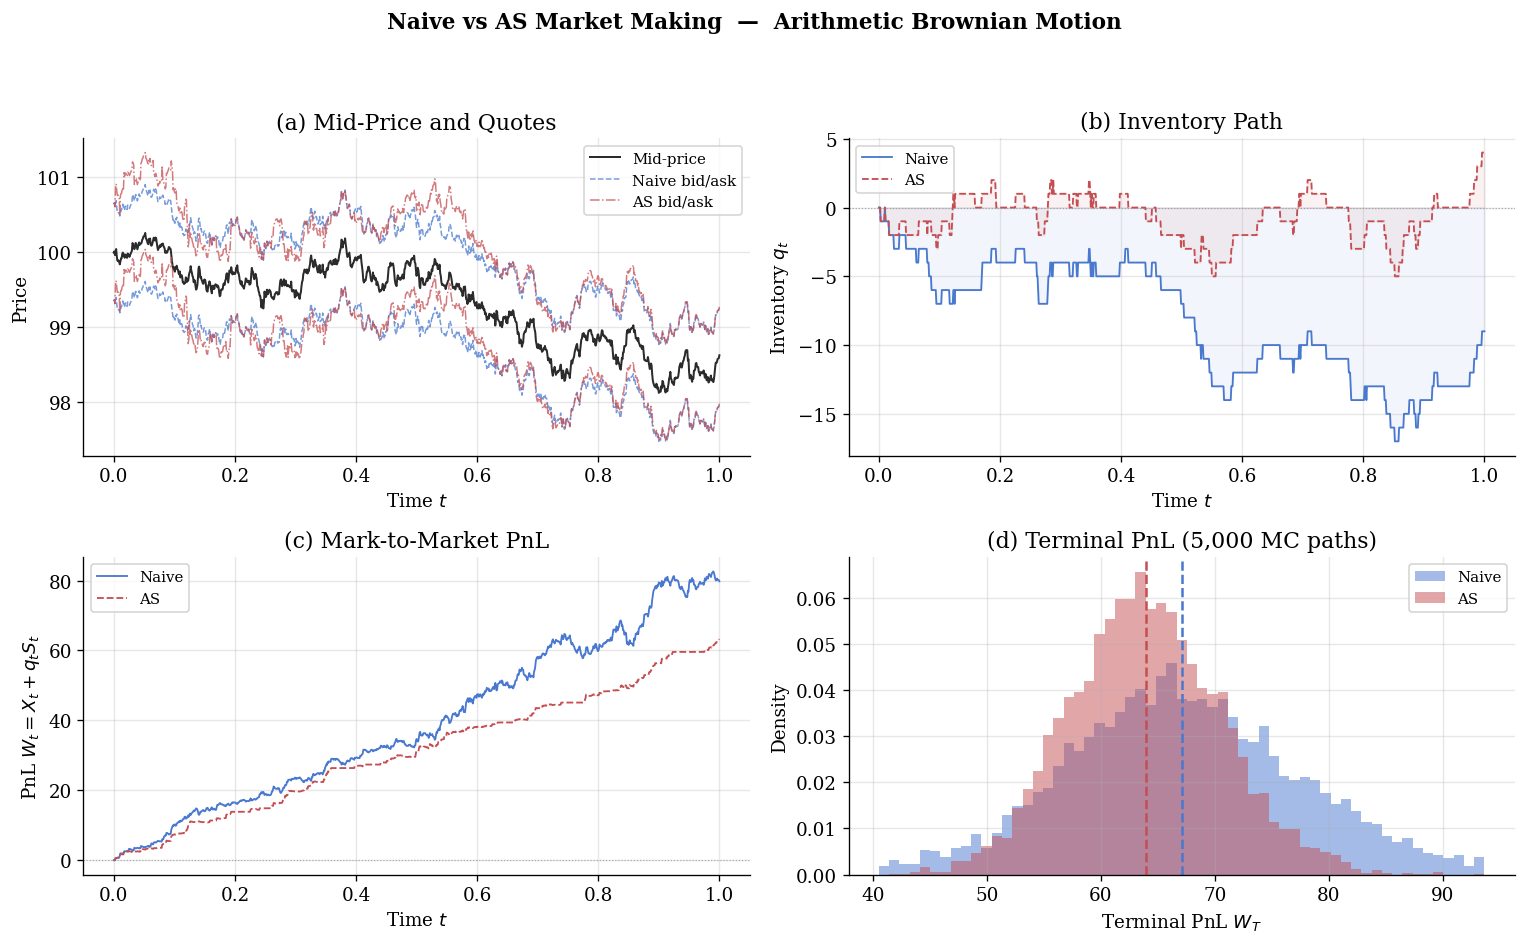

Saved: /content/py1.png


In [ ]:
fig1 = make_figure(t_arr, S_BM, r_naive_BM, r_as_BM, mc_BM,
                   label='Arithmetic Brownian Motion', filename='py1.png')

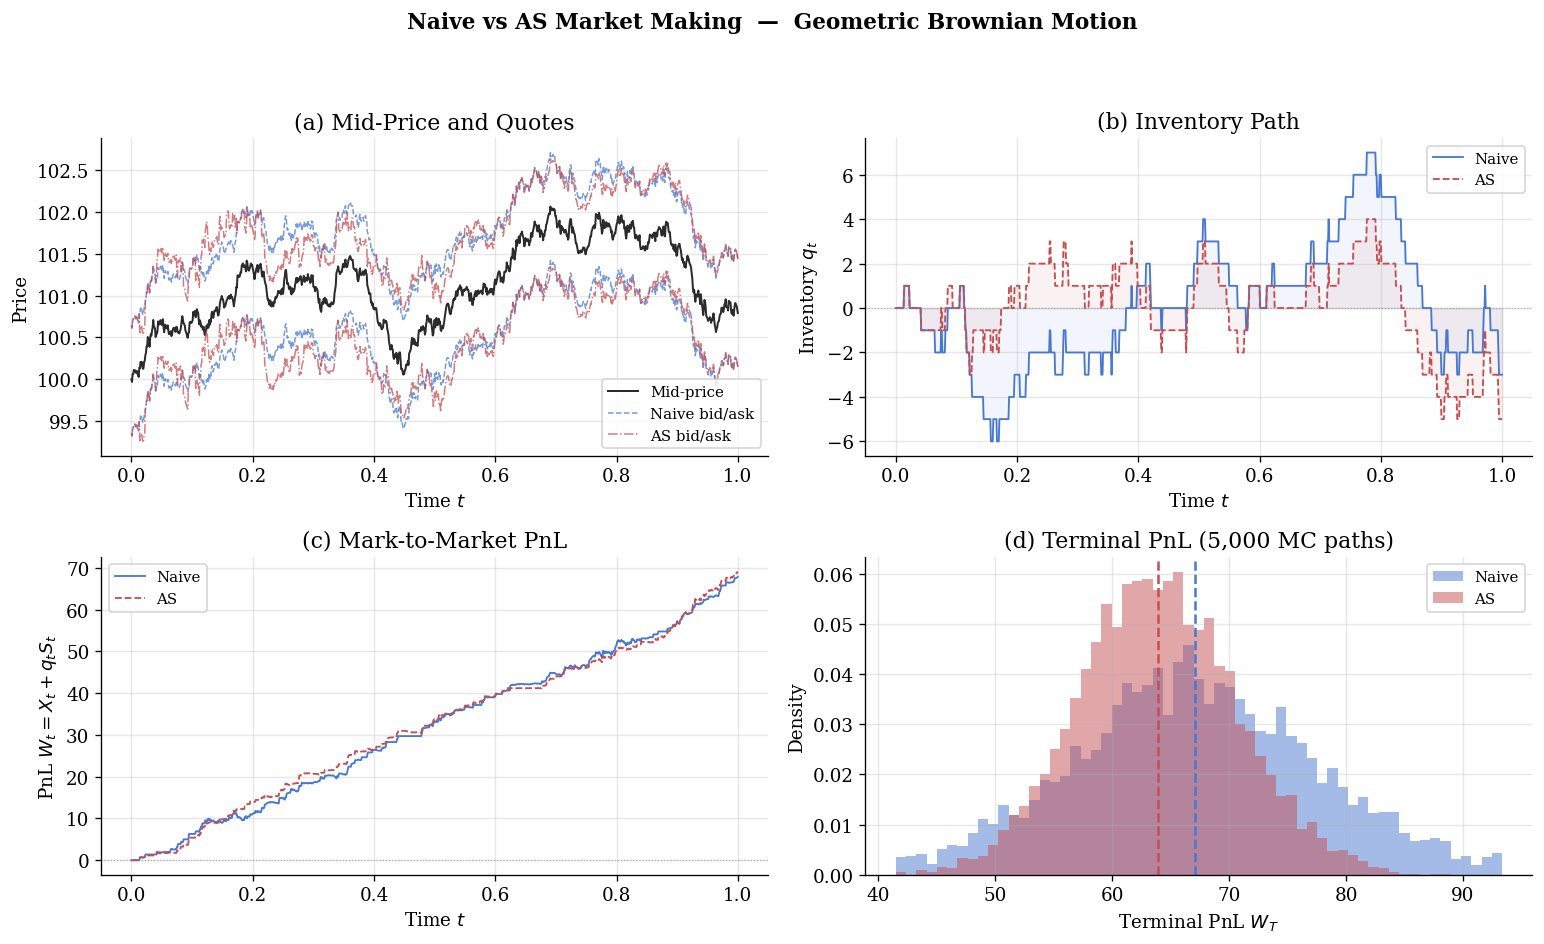

Saved: /content/py2.png


In [ ]:
fig2 = make_figure(t_arr, S_GBM, r_naive_GBM, r_as_GBM, mc_GBM,
                   label='Geometric Brownian Motion', filename='py2.png')

## 9. Multivariate Extension

For $d$ assets, prices and inventories become vectors:

$$
S_t\in\mathbb{R}^d, \qquad q_t\in\mathbb{Z}^d, \qquad X_t\in\mathbb{R}.
$$

Correlated arithmetic Brownian motions are generated via the Cholesky factor $C$
of the instantaneous covariance matrix $\Sigma = CC^\top$:

$$
dS_t = C\,d\widetilde{W}_t, \qquad \widetilde{W}_t\in\mathbb{R}^d\text{ i.i.d. standard BM.}
$$

Mark-to-market wealth is

$$
W_t = X_t + q_t^\top S_t.
$$

The frozen-inventory portfolio variance over the remaining horizon $\tau = T-t$ is

$$
\mathrm{Var}_t\bigl(q_t^\top(S_T - S_t)\bigr) = \tau\,q_t^\top\Sigma\,q_t.
$$

The gradient of the quadratic risk charge with respect to $q$ is the **covariance pressure**:

$$
\nabla_q\!\left(\frac{\gamma}{2}\,\tau\,q_t^\top\Sigma\,q_t\right) = \gamma\,\tau\,\Sigma\,q_t.
$$

This is the key object: quote $i$ reacts to $(\Sigma q_t)_i$, not just $q_t^i$.
A long position in a positively correlated asset $j$ pushes the dealer to tighten the ask of asset $i$; an inversely correlated asset can instead partially hedge the portfolio and may push quotes in the opposite direction.

## 10. Marginal Multi-Asset Reservation Prices

Buying one extra unit of asset $i$ shifts portfolio inventory from $q$ to $q + e_i$.
The marginal change in risk charge is $\gamma\tau(\Sigma q)_i + \tfrac{\gamma}{2}\tau\Sigma_{ii}$.
Splitting bid and ask symmetrically around the covariance-adjusted center gives

$$
r_{i}^{\mathrm{bid}} = S_i - \gamma\tau(\Sigma q)_i - \tfrac{\gamma}{2}\tau\Sigma_{ii},
$$

$$
r_{i}^{\mathrm{ask}} = S_i - \gamma\tau(\Sigma q)_i + \tfrac{\gamma}{2}\tau\Sigma_{ii}.
$$

The final executable quotes add/subtract the per-asset liquidity half-spread $\delta_i^*$:

$$
p_i^b = r_i^{\mathrm{bid}} - \delta_i^*, \qquad p_i^a = r_i^{\mathrm{ask}} + \delta_i^*,
\qquad \delta_i^* = \frac{1}{\gamma}\ln\!\left(1+\frac{\gamma}{k_i}\right).
$$

## 11. Multivariate Simulation — Infrastructure

This section implements the full correlated multi-asset simulation engine.
Fill probabilities use the same exponential intensity model as the single-asset case,
vectorised per asset:

$$
\lambda_i^b(\delta_i^b) = A_i\,e^{-k_i\delta_i^b},
\qquad
P_{\mathrm{fill},i}^b = 1 - e^{-\lambda_i^b\,\Delta t}.
$$

Each asset's cash flow and inventory evolve independently conditioned on the shared
price path; total mark-to-market PnL is $W_t = X_t + q_t^\top S_t$.

In [7]:
def sim_multi_BM(dW, S0, chol_cov):
    '''Correlated arithmetic Brownian motion: dS = C dW_tilde.'''
    n, d = dW.shape
    S = np.empty((n + 1, d))
    S[0] = np.asarray(S0, dtype=float)
    dS = dW @ chol_cov.T
    for i in range(n):
        S[i+1] = S[i] + dS[i]
    return S


# firts risk metric
def portfolio_risk_norm(q, Sigma):
    '''sqrt(q^T Sigma q) — instantaneous portfolio risk.'''
    q = np.asarray(q, dtype=float)
    return float(np.sqrt(max(q @ Sigma @ q, 0.0)))


# second risk metric
def covariance_pressure(q, Sigma):
    '''Sigma @ q — gradient direction of the quadratic inventory penalty.'''
    return Sigma @ np.asarray(q, dtype=float)


# log-returns computation
def cumulative_log_returns(S):
    '''100 * log(S_t / S_0), asset by asset, for comparable plotting.'''
    S = np.asarray(S, dtype=float)
    if np.any(S <= 0):
        raise ValueError('Log-returns require strictly positive simulated prices.')
    return 100.0 * np.log(S / S[0])


def fmt_vec(x, decimals=2):
    '''Compact vector formatter for tables.'''
    arr = np.asarray(x, dtype=float)
    return '[' + ', '.join(f'{v:.{decimals}f}' for v in arr) + ']'


# vectorized fill_probs
def fill_probs_multi(S, p_bid, p_ask, A, k, dt):
    '''Vectorised per-asset fill probabilities.'''
    S = np.asarray(S); p_bid = np.asarray(p_bid); p_ask = np.asarray(p_ask)
    A = np.asarray(A); k = np.asarray(k)
    lam_b = A * np.exp(-k * np.maximum(S - p_bid, 0.0))
    lam_a = A * np.exp(-k * np.maximum(p_ask - S, 0.0))
    return 1.0 - np.exp(-lam_b * dt), 1.0 - np.exp(-lam_a * dt)


# naive strategy
def quote_naive_multi(S, q, t, gamma, k, **_):
    '''Independent symmetric quotes: p^b/a = S -/+ delta*.'''
    S = np.asarray(S, dtype=float)
    delta = (1.0 / gamma) * np.log(1.0 + gamma / np.asarray(k))
    return S - delta, S + delta


# multivariate inventory based strategy
def quote_as_multi_cov(S, q, t, gamma, k, Sigma, T, **_):
    '''Covariance-aware inventory-based quotes.'''
    S = np.asarray(S, dtype=float)
    q = np.asarray(q, dtype=float)
    k = np.asarray(k, dtype=float)
    tau = max(T - t, 0.0)
    pressure = Sigma @ q
    risk_half = 0.5 * gamma * tau * np.diag(Sigma)
    liq_half = (1.0 / gamma) * np.log(1.0 + gamma / k)
    bid_res = S - gamma * tau * pressure - risk_half
    ask_res = S - gamma * tau * pressure + risk_half
    return bid_res - liq_half, ask_res + liq_half


# multivaraite simulation
def run_sim_multi(t_arr, S, U_bid, U_ask, qfn, dt, **kw):
    '''Portfolio accounting for a vector of assets.'''
    A = kw['A']; k = kw['k']
    n, d = S.shape[0] - 1, S.shape[1]
    inv  = np.zeros((n + 1, d), dtype=int)
    cash = np.zeros(n + 1)
    pnl  = np.zeros(n + 1)
    risk = np.zeros(n + 1)
    bids = np.zeros((n + 1, d))
    asks = np.zeros((n + 1, d))
    q = np.zeros(d, dtype=int)
    c = 0.0
    turnover = 0
    Sigma_kw = kw.get('Sigma')
    for i in range(n):
        s = S[i]
        t = t_arr[i]
        pb, pa = qfn(s, q, t, **kw)
        bids[i] = pb
        asks[i] = pa
        pfb, pfa = fill_probs_multi(s, pb, pa, A, k, dt)
        bid_fill = U_bid[i] < pfb
        ask_fill = U_ask[i] < pfa
        q += bid_fill.astype(int)
        c -= float(np.sum(pb * bid_fill))
        q -= ask_fill.astype(int)
        c += float(np.sum(pa * ask_fill))
        turnover += int(np.sum(bid_fill) + np.sum(ask_fill))
        inv[i+1]  = q
        cash[i+1] = c
        pnl[i+1]  = c + float(q @ S[i+1])
        if Sigma_kw is not None:
            risk[i+1] = portfolio_risk_norm(q, Sigma_kw)
    pb, pa = qfn(S[-1], q, t_arr[-1], **kw)
    bids[-1] = pb
    asks[-1] = pa
    gross_inv_path = np.sum(np.abs(inv), axis=1)
    return dict(inv=inv, cash=cash, pnl=pnl, risk=risk, bids=bids, asks=asks,
                turnover=turnover, inv_std=np.std(gross_inv_path))


# extraction of the statistics dictionary
def summarize_multi(res, Sigma):
    qT = res['inv'][-1].astype(float)
    return dict(
        pnl=float(res['pnl'][-1]),
        inv=qT,
        gross_abs_inv=float(np.sum(np.abs(qT))),
        risk_norm=portfolio_risk_norm(qT, Sigma),
        pressure=covariance_pressure(qT, Sigma),
        turnover=float(res['turnover']),
        inv_std=float(res['inv_std']),
        avg_path_risk=float(np.mean(res['risk'])),
        max_path_risk=float(np.max(res['risk'])),
    )

print('Multivariate simulation infrastructure loaded.')


Multivariate simulation infrastructure loaded.


## 12. Three-Asset Toy Example — One Inversely Correlated Asset

The third asset is intentionally inversely correlated with both Asset A and Asset B. This makes the covariance pressure visible: the inventory-based rule reacts to the **portfolio** exposure, not only to each single position in isolation.

In [8]:
# same univariate parameters
T_multi       = P['T']
n_steps_multi = P['n_steps']
dt_multi      = T_multi / n_steps_multi
gamma_multi   = P['gamma']
seed_multi    = P['seed']
N_MC_MULTI    = 3000

# 3 assests
names_multi   = ['Asset A', 'Asset B', 'Asset C (inverse)']
S0_multi      = np.array([100.0,  75.0,  50.0])
sigma_multi   = np.array([  1.50,   1.10,   0.90])
corr_multi    = np.array([[ 1.00,  0.65, -0.55],
                          [ 0.65,  1.00, -0.35],
                          [-0.55, -0.35,  1.00]])
A_multi       = np.array([140.0, 120.0, 100.0])
k_multi       = np.array([  1.50,   1.80,   1.65])

# computation of covariance matrix and Cholevsky factorization
Sigma_multi = np.outer(sigma_multi, sigma_multi) * corr_multi
chol_multi  = np.linalg.cholesky(Sigma_multi)

cov_table = pd.DataFrame(Sigma_multi, index=names_multi, columns=names_multi)
corr_table = pd.DataFrame(corr_multi, index=names_multi, columns=names_multi)

display(corr_table.style.format('{:,.2f}').set_caption('Correlation matrix: Asset C is inversely correlated'))
display(cov_table.style.format('{:,.4f}').set_caption(r'Covariance matrix $\Sigma$'))

# critic scenario test
q_demo = np.array([8, 0, -5])
pb_demo, pa_demo = quote_as_multi_cov(
    S0_multi, q_demo, 0.0, gamma=gamma_multi, k=k_multi,
    Sigma=Sigma_multi, T=T_multi, A=A_multi
)

demo_table = pd.DataFrame({
    'Quantity': [
        fmt_vec(q_demo, 0),
        fmt_vec(covariance_pressure(q_demo, Sigma_multi), 3),
        fmt_vec(pb_demo, 3),
        fmt_vec(pa_demo, 3),
    ]
}, index=['Demo inventory q', 'Covariance pressure Σq', 'Inventory-based bid', 'Inventory-based ask'])

display(demo_table.style.set_caption('Toy inventory check — inverse asset changes the portfolio pressure'))


,Asset A,Asset B,Asset C (inverse)
Asset A,1.00,0.65,-0.55
Asset B,0.65,1.00,-0.35
Asset C (inverse),-0.55,-0.35,1.00


,Asset A,Asset B,Asset C (inverse)
Asset A,2.2500,1.0725,-0.7425
Asset B,1.0725,1.2100,-0.3465
Asset C (inverse),-0.7425,-0.3465,0.8100


,Quantity
Demo inventory q,"[8, 0, -5]"
Covariance pressure Σq,"[21.713, 10.313, -9.990]"
Inventory-based bid,"[97.071, 73.368, 50.370]"
Inventory-based ask,"[98.587, 74.570, 51.628]"


In [9]:
# correlation matrix image generation
def plot_correlation_matrix(output_path="img/1/Corr.png"):
    labels = ["Asset A", "Asset B", "Asset C\n(inverse)"]

    corr = np.array([
        [1.00,  0.65, -0.55],
        [0.65,  1.00, -0.35],
        [-0.55, -0.35,  1.00]
    ])

    corr_df = pd.DataFrame(corr, index=labels, columns=labels)

    output_dir = os.path.dirname(output_path)
    if output_dir:
        os.makedirs(output_dir, exist_ok=True)

    fig, ax = plt.subplots(figsize=(5.2, 4.2))

    im = ax.imshow(corr_df.values, vmin=-1, vmax=1, cmap="coolwarm")

    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)

    plt.setp(
        ax.get_xticklabels(),
        rotation=35,
        ha="right",
        rotation_mode="anchor"
    )

    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(
                j, i, f"{corr_df.iloc[i, j]:.2f}",
                ha="center",
                va="center",
                fontsize=10
            )

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Correlation")

    ax.set_title("Correlation Matrix", fontsize=12, pad=10)

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.close(fig)

    print(f"Correlation matrix saved to: {output_path}")

plot_correlation_matrix()

Correlation matrix saved to: img/1/Corr.png


In [ ]:
# single-path simulation
rng_multi = np.random.default_rng(seed_multi)
t_arr_multi = np.linspace(0, T_multi, n_steps_multi + 1)
dW_multi = rng_multi.normal(0, np.sqrt(dt_multi), (n_steps_multi, 3))
Ub_multi = rng_multi.random((n_steps_multi, 3))
Ua_multi = rng_multi.random((n_steps_multi, 3))

S_multi = sim_multi_BM(dW_multi, S0_multi, chol_multi)

kw_naive_multi = dict(gamma=gamma_multi, k=k_multi, A=A_multi,
                      Sigma=Sigma_multi, T=T_multi)
kw_as_multi = dict(gamma=gamma_multi, k=k_multi, A=A_multi,
                   Sigma=Sigma_multi, T=T_multi)

r_naive_multi = run_sim_multi(t_arr_multi, S_multi, Ub_multi, Ua_multi,
                              quote_naive_multi, dt_multi, **kw_naive_multi)
r_as_multi = run_sim_multi(t_arr_multi, S_multi, Ub_multi, Ua_multi,
                           quote_as_multi_cov, dt_multi, **kw_as_multi)

sn_multi = summarize_multi(r_naive_multi, Sigma_multi)
sa_multi = summarize_multi(r_as_multi, Sigma_multi)

single_path_multi_summary = pd.DataFrame([
    {
        'Strategy': label,
        'Terminal PnL': out['pnl'],
        'Terminal |q|_1': out['gross_abs_inv'],
        'Terminal risk ||q_T||_Σ': out['risk_norm'],
        'Average path risk': out['avg_path_risk'],
        'Max path risk': out['max_path_risk'],
        'Turnover': out['turnover'],
        'Std(|q_t|_1)': out['inv_std'],
        'Terminal inventory q_T': fmt_vec(out['inv'], 0),
        'Covariance pressure Σq_T': fmt_vec(out['pressure'], 3),
    }
    for label, out in [('Naive', sn_multi), ('Inventory-based', sa_multi)]
]).set_index('Strategy')

display(
    single_path_multi_summary.style
    .format({
        'Terminal PnL': '{:,.3f}',
        'Terminal |q|_1': '{:,.0f}',
        'Terminal risk ||q_T||_Σ': '{:,.3f}',
        'Average path risk': '{:,.3f}',
        'Max path risk': '{:,.3f}',
        'Turnover': '{:,.0f}',
        'Std(|q_t|_1)': '{:,.3f}',
    })
    .set_caption('Multivariate single reference path — terminal and path diagnostics')
)


,Terminal PnL,Terminal |q|_1,Terminal risk ||q_T||_Σ,Average path risk,Max path risk,Turnover,Std(|q_t|_1),Terminal inventory q_T,Covariance pressure Σq_T
Strategy,,,,,,,,,
Naive,158.700,28,16.638,7.912,16.638,262,5.046,"[8, -8, -12]","[18.330, 3.058, -12.888]"
Inventory-based,159.385,15,10.192,3.580,10.192,261,2.736,"[4, -3, -8]","[11.723, 3.432, -8.411]"


## 13. Multivariate Monte Carlo Diagnostic

We run $N=500$ independent Monte Carlo paths (reduced from 5,000 for interactive use)
and compare the terminal distribution of

$$
W_T = X_T + q_T^\top S_T,
\qquad
\|q_T\|_1 = \sum_{i=1}^d |q_T^i|,
\qquad
\|q_T\|_\Sigma = \sqrt{q_T^\top\Sigma\,q_T}.
$$

The last metric is the instantaneous portfolio risk at the terminal inventory.

In [ ]:
print(f'Running multivariate Monte Carlo ({N_MC_MULTI} paths) ...')
master_multi = np.random.default_rng(3000)
dW_all_multi = master_multi.normal(0, np.sqrt(dt_multi), (N_MC_MULTI, n_steps_multi, 3))
Ub_all_multi = master_multi.random((N_MC_MULTI, n_steps_multi, 3))
Ua_all_multi = master_multi.random((N_MC_MULTI, n_steps_multi, 3))

pnl_n_multi  = np.zeros(N_MC_MULTI)
pnl_as_multi = np.zeros(N_MC_MULTI)
gabs_n_multi = np.zeros(N_MC_MULTI)
gabs_as_multi = np.zeros(N_MC_MULTI)
risk_n_multi = np.zeros(N_MC_MULTI)
risk_as_multi = np.zeros(N_MC_MULTI)
maxrisk_n_multi = np.zeros(N_MC_MULTI)
maxrisk_as_multi = np.zeros(N_MC_MULTI)
avgrisk_n_multi = np.zeros(N_MC_MULTI)
avgrisk_as_multi = np.zeros(N_MC_MULTI)
turnover_n_multi = np.zeros(N_MC_MULTI)
turnover_as_multi = np.zeros(N_MC_MULTI)
inv_std_n_multi = np.zeros(N_MC_MULTI)
inv_std_as_multi = np.zeros(N_MC_MULTI)

for m in range(N_MC_MULTI):
    S_m = sim_multi_BM(dW_all_multi[m], S0_multi, chol_multi)
    rn = run_sim_multi(t_arr_multi, S_m, Ub_all_multi[m], Ua_all_multi[m],
                       quote_naive_multi, dt_multi, **kw_naive_multi)
    ra = run_sim_multi(t_arr_multi, S_m, Ub_all_multi[m], Ua_all_multi[m],
                       quote_as_multi_cov, dt_multi, **kw_as_multi)
    sn_m = summarize_multi(rn, Sigma_multi)
    sa_m = summarize_multi(ra, Sigma_multi)
    pnl_n_multi[m]  = sn_m['pnl']
    pnl_as_multi[m] = sa_m['pnl']
    gabs_n_multi[m] = sn_m['gross_abs_inv']
    gabs_as_multi[m] = sa_m['gross_abs_inv']
    risk_n_multi[m] = sn_m['risk_norm']
    risk_as_multi[m] = sa_m['risk_norm']
    maxrisk_n_multi[m] = sn_m['max_path_risk']
    maxrisk_as_multi[m] = sa_m['max_path_risk']
    avgrisk_n_multi[m] = sn_m['avg_path_risk']
    avgrisk_as_multi[m] = sa_m['avg_path_risk']
    turnover_n_multi[m] = sn_m['turnover']
    turnover_as_multi[m] = sa_m['turnover']
    inv_std_n_multi[m] = sn_m['inv_std']
    inv_std_as_multi[m] = sa_m['inv_std']

mc_multi = dict(
    pnl_n=pnl_n_multi, pnl_as=pnl_as_multi,
    inv_n=gabs_n_multi, inv_as=gabs_as_multi,
    risk_n=risk_n_multi, risk_as=risk_as_multi,
    maxrisk_n=maxrisk_n_multi, maxrisk_as=maxrisk_as_multi,
    avgrisk_n=avgrisk_n_multi, avgrisk_as=avgrisk_as_multi,
    turnover_naive=turnover_n_multi, turnover_as=turnover_as_multi,
    inv_std_naive=inv_std_n_multi, inv_std_as=inv_std_as_multi,
)

st_multi = {
    'Multivariate Naive': stats(mc_multi['pnl_n'], mc_multi['inv_n'],
                                mc_multi['turnover_naive'], mc_multi['inv_std_naive']),
    'Multivariate Inventory-based': stats(mc_multi['pnl_as'], mc_multi['inv_as'],
                                          mc_multi['turnover_as'], mc_multi['inv_std_as']),
}

multi_stats_table = pd.DataFrame(st_multi).rename(index=metric_labels)
multi_stats_table.loc['Mean terminal risk ||q_T||_Σ'] = [np.mean(risk_n_multi), np.mean(risk_as_multi)]
multi_stats_table.loc['Median terminal risk ||q_T||_Σ'] = [np.median(risk_n_multi), np.median(risk_as_multi)]
multi_stats_table.loc['Mean average path risk'] = [np.mean(avgrisk_n_multi), np.mean(avgrisk_as_multi)]
multi_stats_table.loc['Mean max path risk'] = [np.mean(maxrisk_n_multi), np.mean(maxrisk_as_multi)]
multi_stats_table['Inventory-based − Naive'] = (
    multi_stats_table['Multivariate Inventory-based'] - multi_stats_table['Multivariate Naive']
)

display(
    multi_stats_table.style
    .format('{:,.3f}')
    .set_caption(f'Multivariate Monte Carlo diagnostics — {N_MC_MULTI} simulated paths')
)

print('Multivariate MC done.')
print('=== Multivariate LaTeX rows ===')
for label, row in multi_stats_table.iterrows():
    print(f'{label} & {row["Multivariate Naive"]:.3f} & {row["Multivariate Inventory-based"]:.3f} & {row["Inventory-based − Naive"]:.3f} \\\\')


Running multivariate Monte Carlo (3000 paths) ...


,Multivariate Naive,Multivariate Inventory-based,Inventory-based − Naive
Mean terminal PnL,158.709,154.556,-4.153
Std terminal PnL,16.439,10.547,-5.892
Sharpe-like ratio,9.654,14.654,5.000
Mean |terminal inv|,21.949,11.203,-10.745
Mean Std(q_t),6.593,3.397,-3.195
Mean Turnover,266.641,257.767,-8.874
Mean terminal risk ||q_T||_Σ,17.051,7.419,-9.632
Median terminal risk ||q_T||_Σ,15.313,6.996,-8.318
Mean average path risk,11.397,3.925,-7.472
Mean max path risk,22.638,10.065,-12.573


Multivariate MC done.
=== Multivariate LaTeX rows ===
Mean terminal PnL & 158.709 & 154.556 & -4.153 \\
Std terminal PnL & 16.439 & 10.547 & -5.892 \\
Sharpe-like ratio & 9.654 & 14.654 & 5.000 \\
Mean |terminal inv| & 21.949 & 11.203 & -10.745 \\
Mean Std(q_t) & 6.593 & 3.397 & -3.195 \\
Mean Turnover & 266.641 & 257.767 & -8.874 \\
Mean terminal risk ||q_T||_Σ & 17.051 & 7.419 & -9.632 \\
Median terminal risk ||q_T||_Σ & 15.313 & 6.996 & -8.318 \\
Mean average path risk & 11.397 & 3.925 & -7.472 \\
Mean max path risk & 22.638 & 10.065 & -12.573 \\


## 14. Multivariate Figure Export

The 2×2 figure below shows, for the single reference path:

- **(a)** cumulative log-returns $100\log(S_t^i/S_0^i)$, so assets with different price levels are comparable on the same plot;
- **(b)** portfolio PnL $W_t = X_t + q_t^\top S_t$ for naive vs inventory-based;
- **(c)** portfolio risk norm $\|q_t\|_\Sigma$ over time;
- **(d)** terminal PnL histogram over all $N$ Monte Carlo paths.


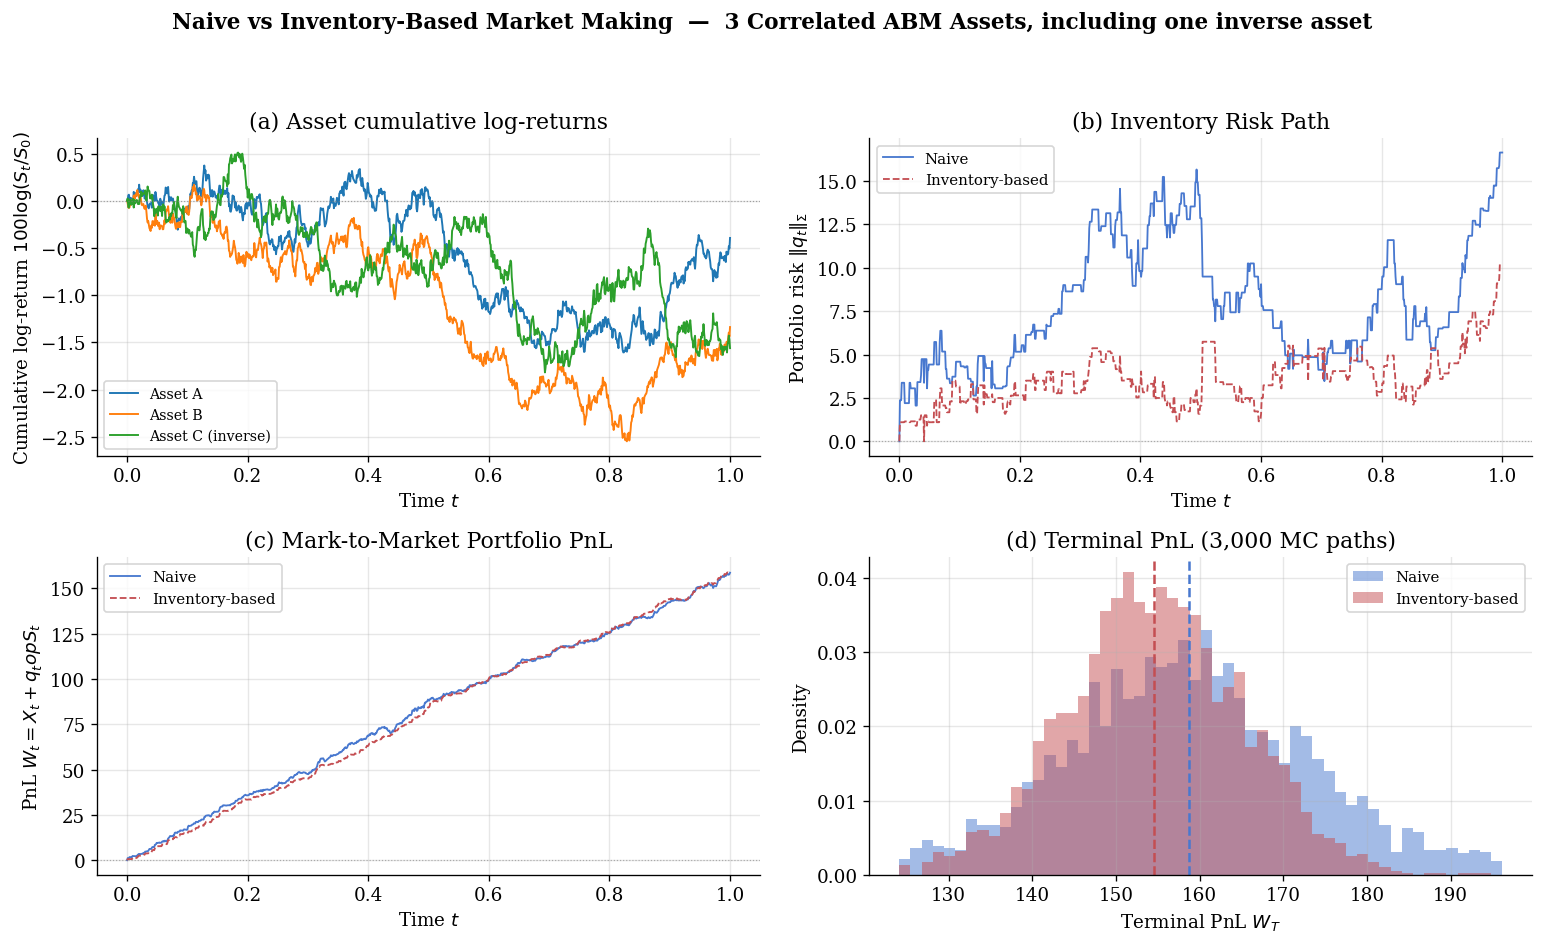

Saved: /content/py3.png


In [ ]:
def make_figure_multi(t_arr, S, r_naive, r_as, mc_res, names, label, filename):
    fig, axes = plt.subplots(2, 2, figsize=(13, 8))
    fig.suptitle(f'Naive vs Inventory-Based Market Making  —  {label}',
                 fontsize=13, fontweight='bold')

    ax = axes[0,0]
    log_ret = cumulative_log_returns(S)
    for j, nm in enumerate(names):
        ax.plot(t_arr, log_ret[:, j], lw=1.15, label=nm)
    ax.axhline(0, color='gray', lw=0.7, ls=':', alpha=0.7)
    ax.set_xlabel('Time $t$')
    ax.set_ylabel(r'Cumulative log-return $100\log(S_t/S_0)$')
    ax.set_title('(a) Asset cumulative log-returns')
    ax.legend(fontsize=8.5)

    ax = axes[0,1]
    ax.plot(t_arr, r_naive['risk'], color=COLORS['naive'], lw=1.1, label='Naive')
    ax.plot(t_arr, r_as['risk'],    color=COLORS['AS'],    lw=1.1, ls='--', label='Inventory-based')
    ax.axhline(0, color='gray', lw=0.7, ls=':', alpha=0.6)
    ax.set_xlabel('Time $t$')
    ax.set_ylabel(r'Portfolio risk $\|q_t\|_\Sigma$')
    ax.set_title(r'(b) Inventory Risk Path')
    ax.legend(fontsize=9)

    ax = axes[1,0]
    ax.plot(t_arr, r_naive['pnl'], color=COLORS['naive'], lw=1.1, label='Naive')
    ax.plot(t_arr, r_as['pnl'],    color=COLORS['AS'],    lw=1.1, ls='--', label='Inventory-based')
    ax.axhline(0, color='gray', lw=0.7, ls=':', alpha=0.6)
    ax.set_xlabel('Time $t$')
    ax.set_ylabel(r'PnL $W_t = X_t + q_t^	op S_t$')
    ax.set_title('(c) Mark-to-Market Portfolio PnL')
    ax.legend(fontsize=9)

    ax = axes[1,1]
    all_v = np.concatenate([mc_res['pnl_n'], mc_res['pnl_as']])
    lo, hi = np.percentile(all_v, 1), np.percentile(all_v, 99)
    bins = np.linspace(lo, hi, 55)
    ax.hist(mc_res['pnl_n'],  bins=bins, color=COLORS['naive'], alpha=0.50, density=True, label='Naive')
    ax.hist(mc_res['pnl_as'], bins=bins, color=COLORS['AS'],    alpha=0.50, density=True, label='Inventory-based')
    ax.axvline(np.mean(mc_res['pnl_n']),  color=COLORS['naive'], lw=1.5, ls='--')
    ax.axvline(np.mean(mc_res['pnl_as']), color=COLORS['AS'],    lw=1.5, ls='--')
    ax.set_xlabel('Terminal PnL $W_T$')
    ax.set_ylabel('Density')
    ax.set_title(f'(d) Terminal PnL ({N_MC_MULTI:,} MC paths)')
    ax.legend(fontsize=9)

    fig.tight_layout(rect=[0,0,1,0.94])
    path = os.path.join(OUTPUT_DIR, filename)
    fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {path}')
    return fig

fig3 = make_figure_multi(t_arr_multi, S_multi, r_naive_multi, r_as_multi, mc_multi,
                         names_multi,
                         label='3 Correlated ABM Assets, including one inverse asset',
                         filename='py3.png')



=== FINAL CHECK ===
  py1.png: OK  (309,667 bytes)


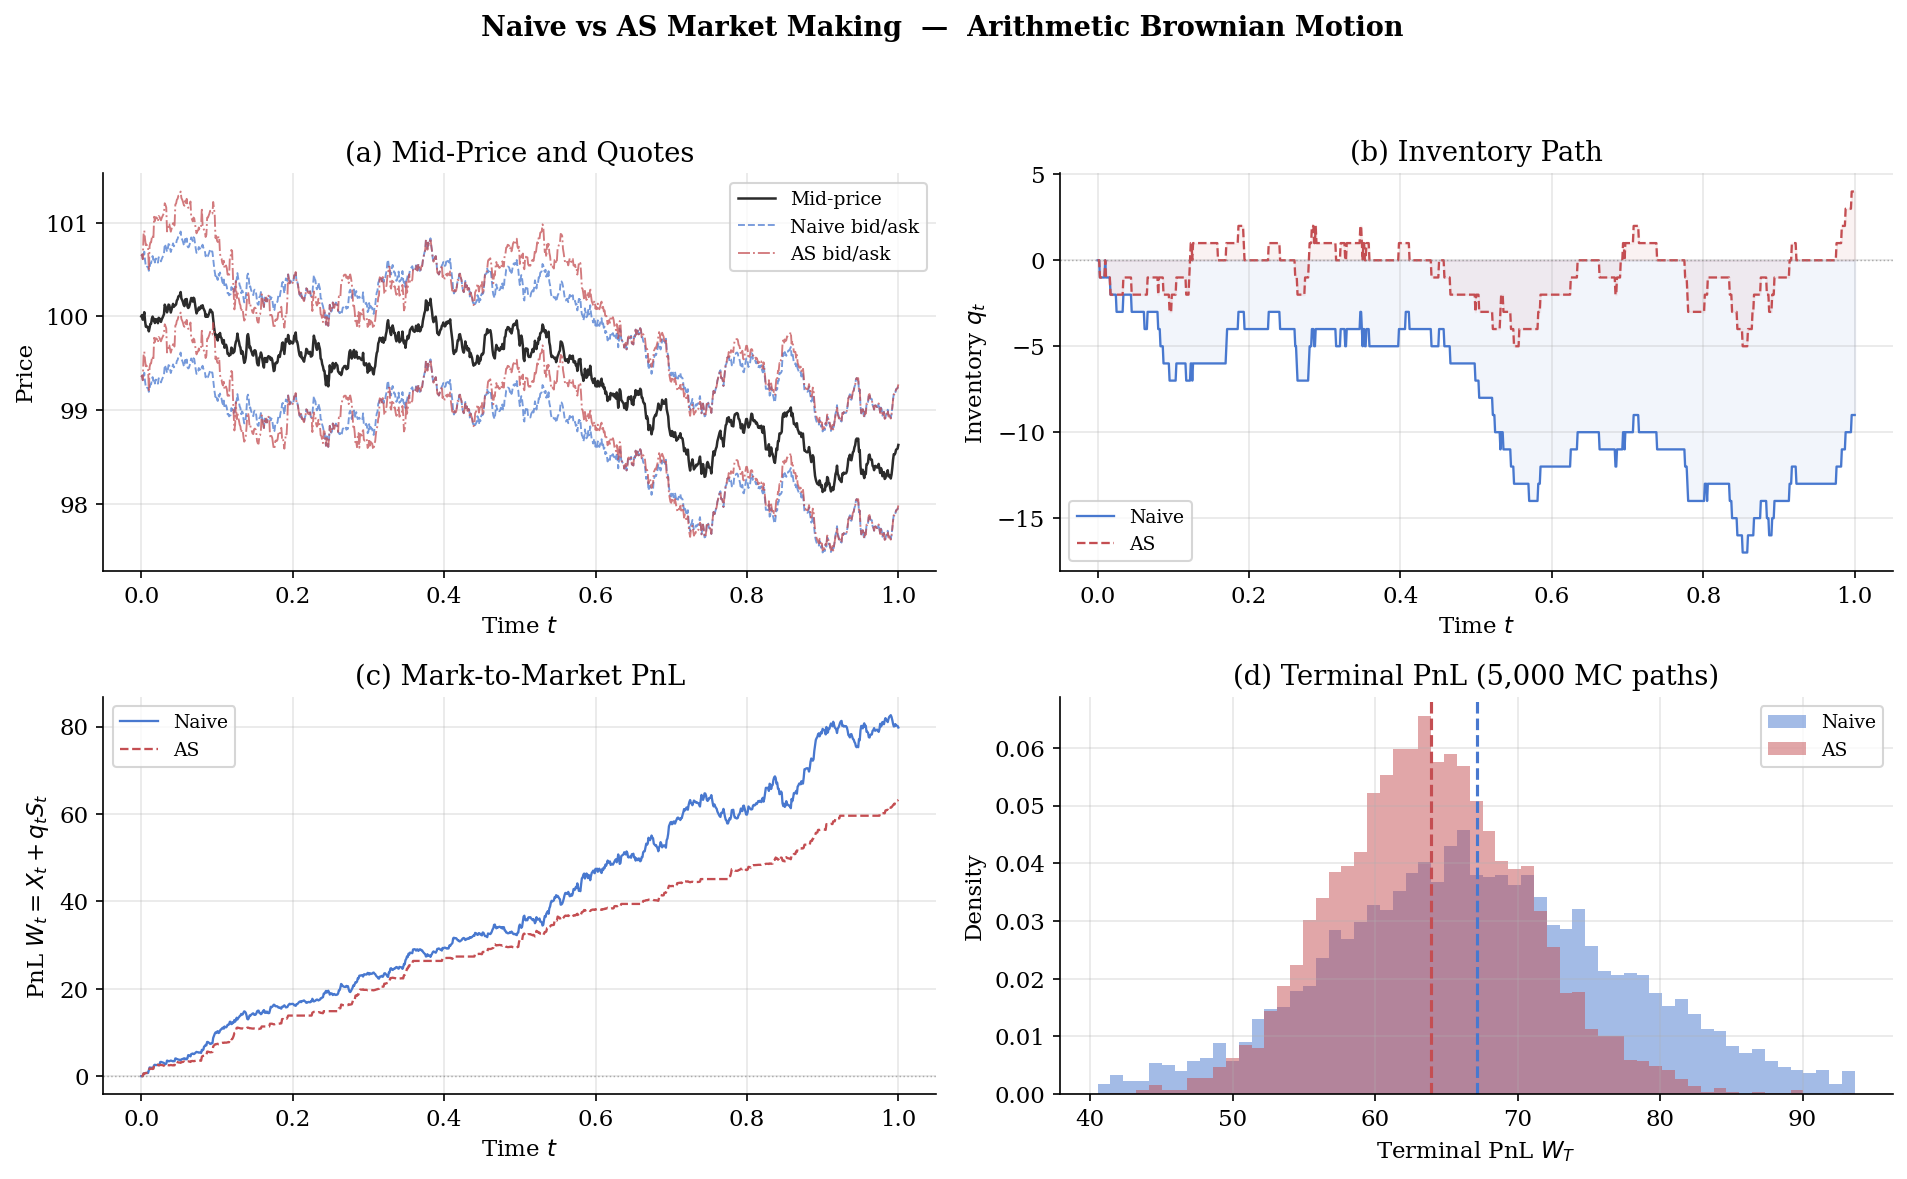

  py2.png: OK  (336,053 bytes)


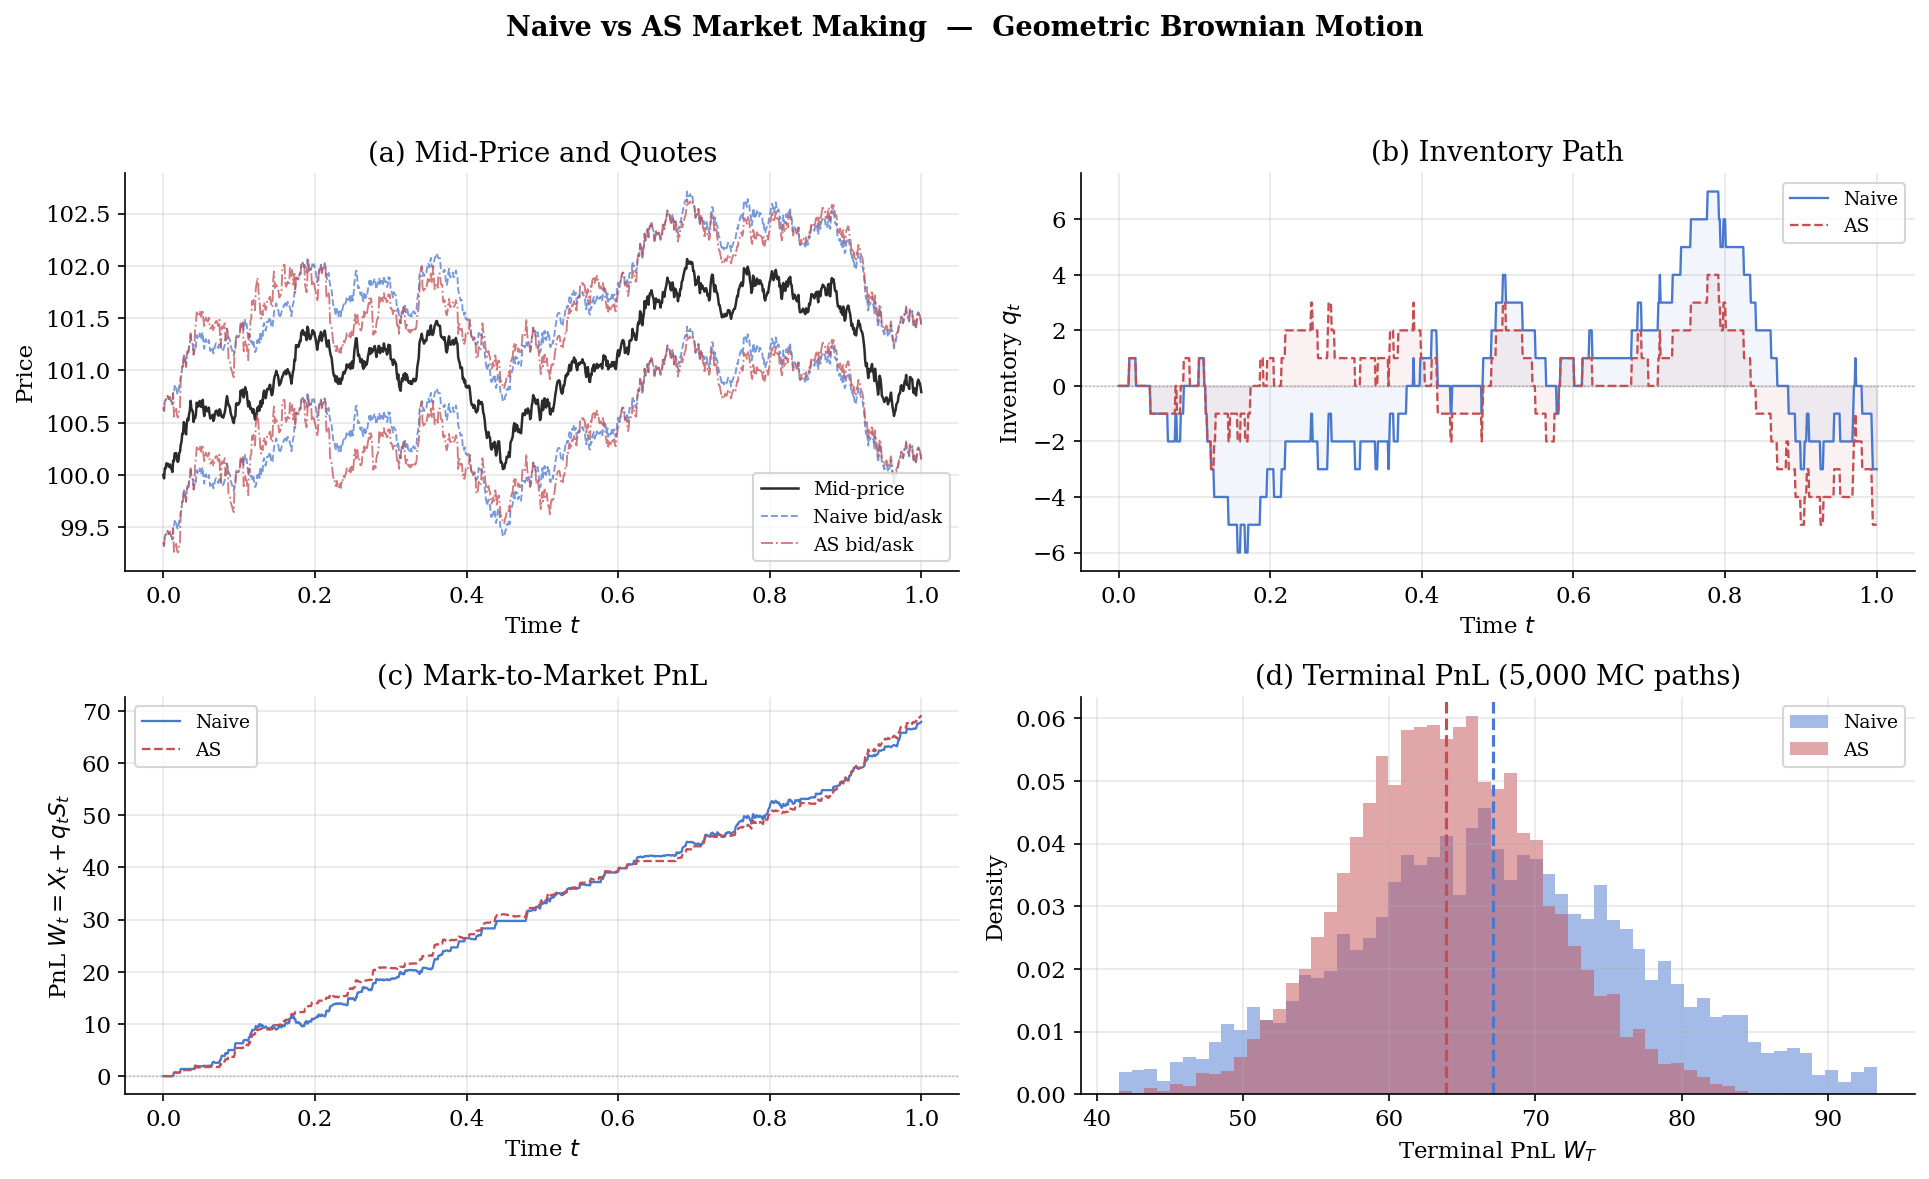

  py3.png: OK  (315,654 bytes)


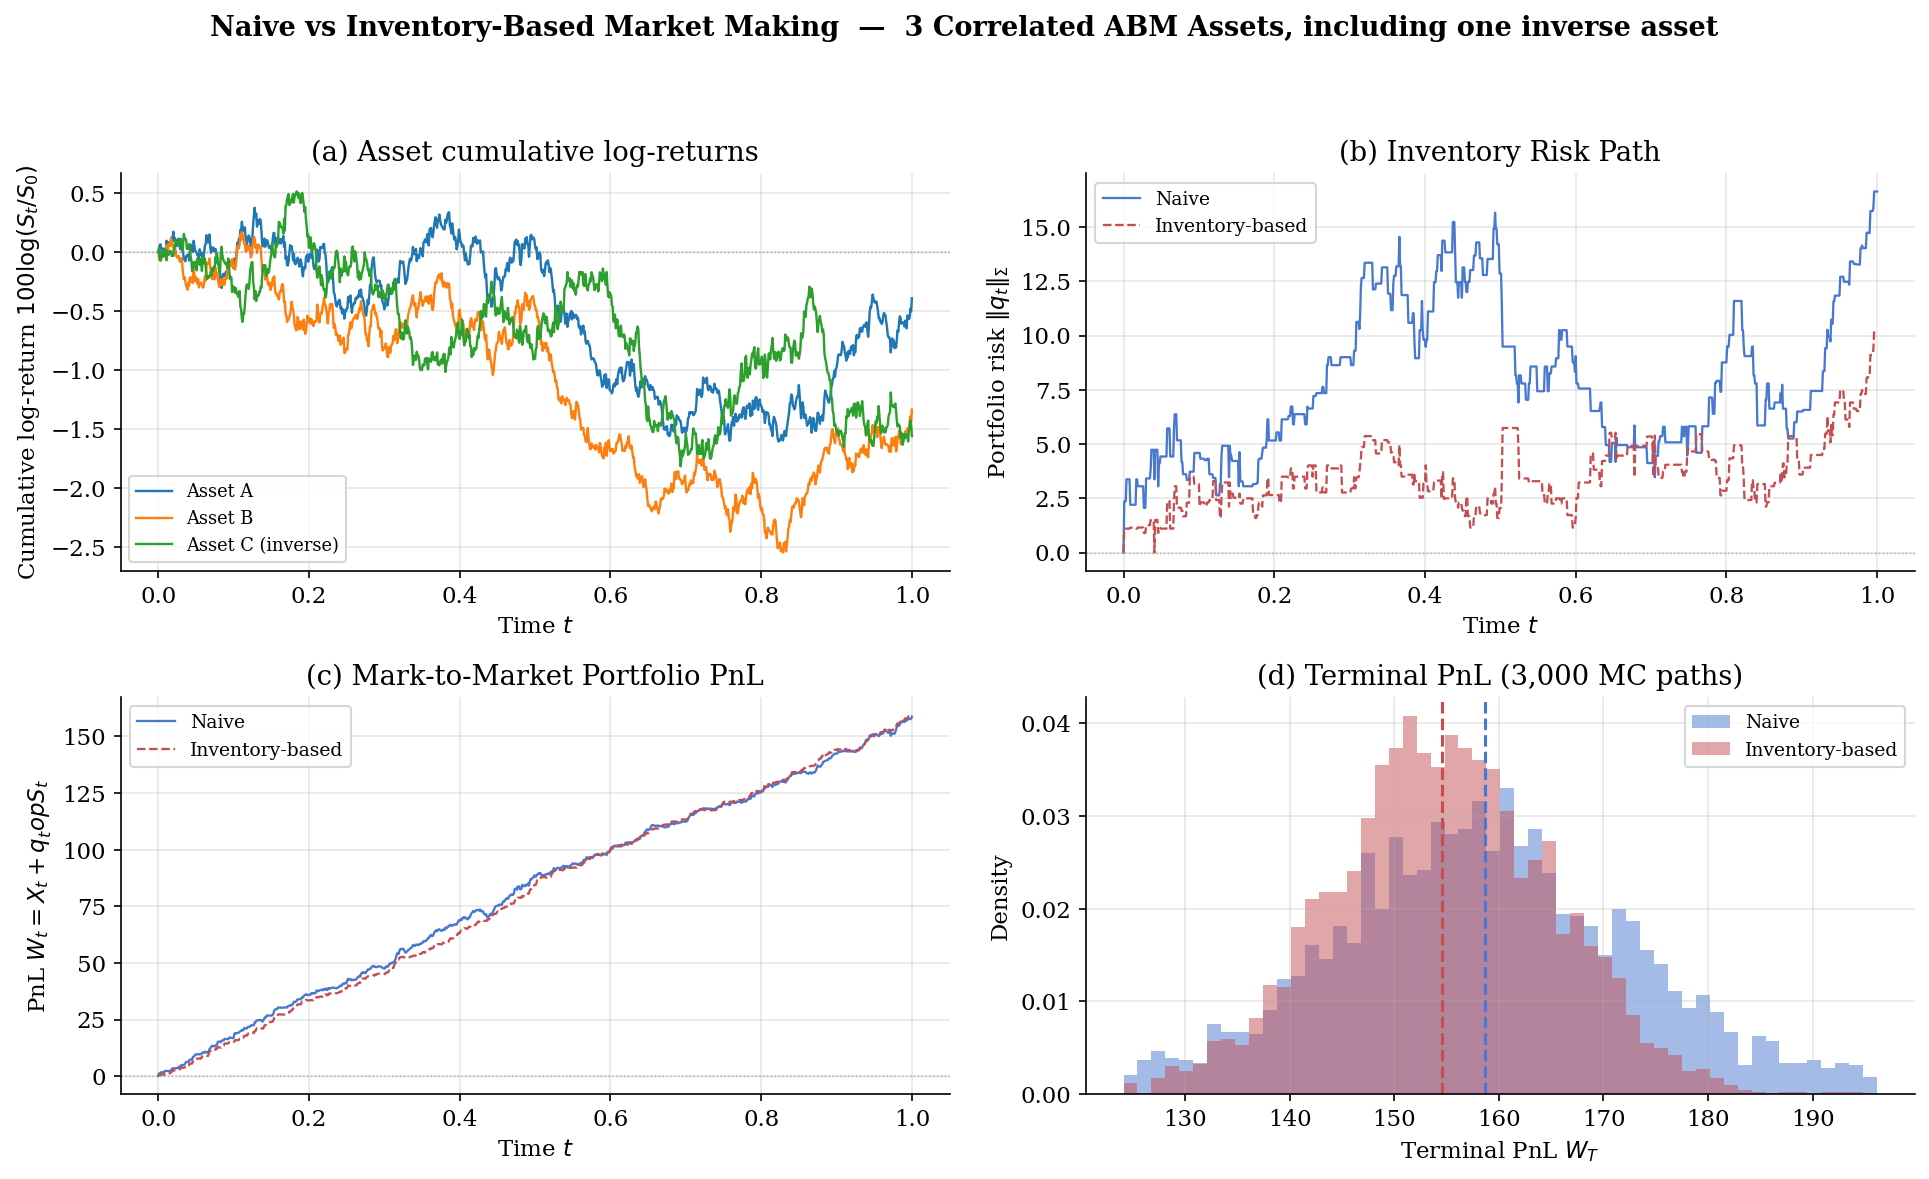

In [ ]:
print('\n=== FINAL CHECK ===')
for fname in ['py1.png', 'py2.png', 'py3.png']:
    full = os.path.join(OUTPUT_DIR, fname)
    ok = os.path.isfile(full)
    size = os.path.getsize(full) if ok else 0
    print(f'  {fname}: {"OK" if ok else "MISSING"}  ({size:,} bytes)')
    if ok:
        display(Image(filename=full))


## 15. References

- Avellaneda and Stoikov (2008), *High-frequency trading in a limit order book*.
- Cartea, Jaimungal, and Penalva (2015), *Algorithmic and High-Frequency Trading*.
- Guéant (2016), *The Financial Mathematics of Market Liquidity: From Optimal Execution to Market Making*.
- Bergault, Evangelista, Guéant, and Vieira (2022), *Closed-form approximations in multi-asset market making*.